# NIH Chest X-ray Metadata EDA

Exploratory analyis of `Data_Entry_2017.csv` and `BBox_List_2017.csv`

In [1]:
# Run if needed 
# %pip install opencv-python 

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
import cv2
import glob

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
%matplotlib inline

In [3]:
# Paths
DATA_ENTRY_2017_PATH = 'data/Data_Entry_2017.csv'
BBOX_PATH = 'data/BBox_List_2017.csv'
IMAGE_PATHS = 'images/images_*/images/*.png'

# Dataset Overview (Data_Entry_2017.csv)

In [4]:
df = pd.read_csv(DATA_ENTRY_2017_PATH)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [5]:
# Number of duplicate rows
duplicates = df.duplicated().sum()

# Total images
total_images = df.shape[0]

# Unique patients
unique_patients = df['Patient ID'].nunique()

# Number of unique findings
unique_findings = df['Finding Labels'].nunique()

# Average images per patient
avg_images_per_patient = total_images / unique_patients

print(f"Number of duplicate rows: {duplicates}")
print(f"Total images: {total_images}")
print(f"Unique patients: {unique_patients}")
print(f"Number of unique findings: {unique_findings}")
print(f"Average images per patient: {avg_images_per_patient:.2f}") # Also indicated through follow up #

Number of duplicate rows: 0
Total images: 112120
Unique patients: 30805
Number of unique findings: 836
Average images per patient: 3.64


View Position
PA    67310
AP    44810
Name: count, dtype: int64


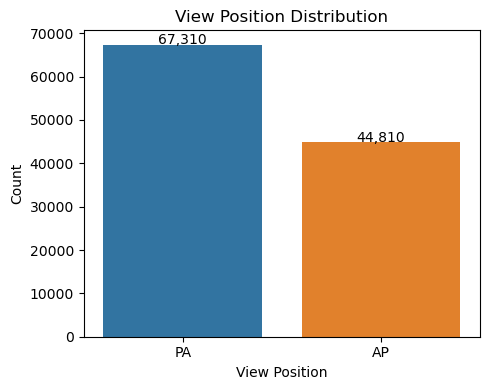

In [6]:
view_counts = df['View Position'].value_counts()
print(view_counts)

plt.figure(figsize=(5, 4))
sns.barplot(x=view_counts.index, y=view_counts.values, hue=view_counts.index)
plt.title('View Position Distribution')
plt.ylabel('Count')
for i, v in enumerate(view_counts.values):
    plt.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
# Will need cleaning to separate multiple labels
df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                         60361
Infiltration                                                        9547
Atelectasis                                                         4215
Effusion                                                            3955
Nodule                                                              2705
                                                                   ...  
Atelectasis|Consolidation|Edema|Effusion|Infiltration|Pneumonia        1
Atelectasis|Consolidation|Effusion|Emphysema|Mass|Pneumothorax         1
Cardiomegaly|Effusion|Pleural_Thickening|Pneumothorax                  1
Edema|Infiltration|Pneumothorax                                        1
Atelectasis|Consolidation|Mass|Pleural_Thickening|Pneumothorax         1
Name: count, Length: 836, dtype: int64

In [8]:
# Separate Finding Labels into individual labels
all_labels = df['Finding Labels'].str.split('|').explode()
label_counts = all_labels.value_counts().sort_values()

counts_fig = px.bar(x=label_counts.values, 
             y=label_counts.index,
             orientation='h', 
             text=label_counts.values,
             title='Pathology Counts (Across All Images)',
             labels={'x': 'Count', 'y': 'Pathology'},
             color=label_counts.values, 
             color_continuous_scale='RdYlBu')
counts_fig.update_traces(textposition='outside')
counts_fig.update_layout(width=1050, height=600)
counts_fig.show()



In [9]:
df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,0.0
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649,NaN
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174,NaN
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,NaN
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000,NaN
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000,NaN
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,NaN
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800,NaN


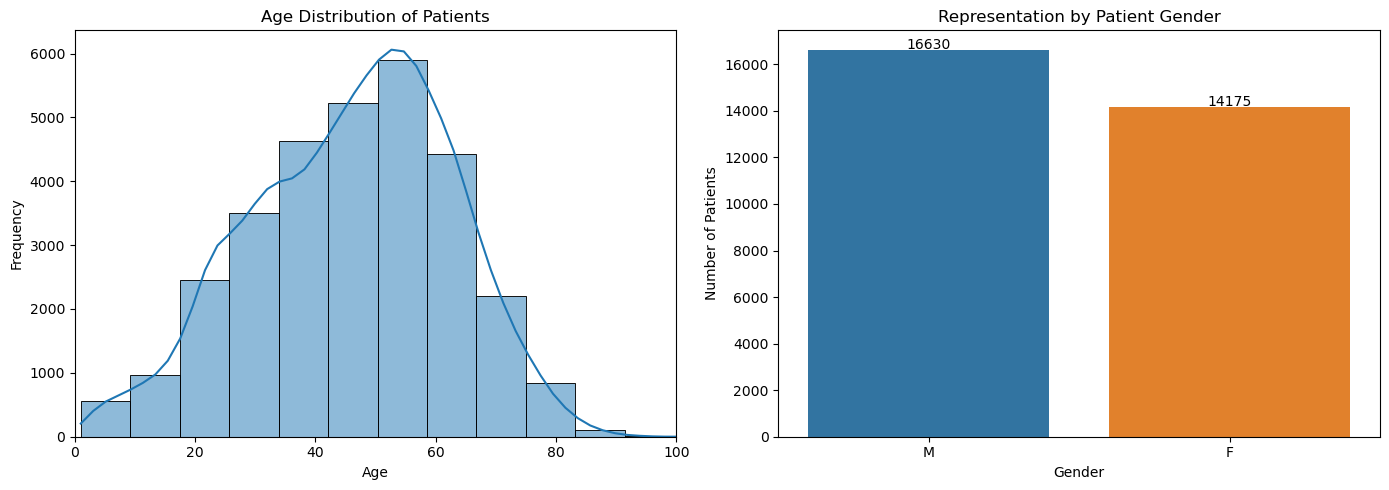

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution
patient_df = df.groupby('Patient ID').first().reset_index()
sns.histplot(patient_df['Patient Age'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution of Patients')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 100)

# Gender Distribution
gender_counts = patient_df['Patient Gender'].value_counts()
sns.countplot(data=patient_df, x='Patient Gender', ax=axes[1], hue='Patient Gender')
axes[1].set_title('Representation by Patient Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Patients')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=10)

plt.tight_layout()  # Prevents overlapping
plt.show()

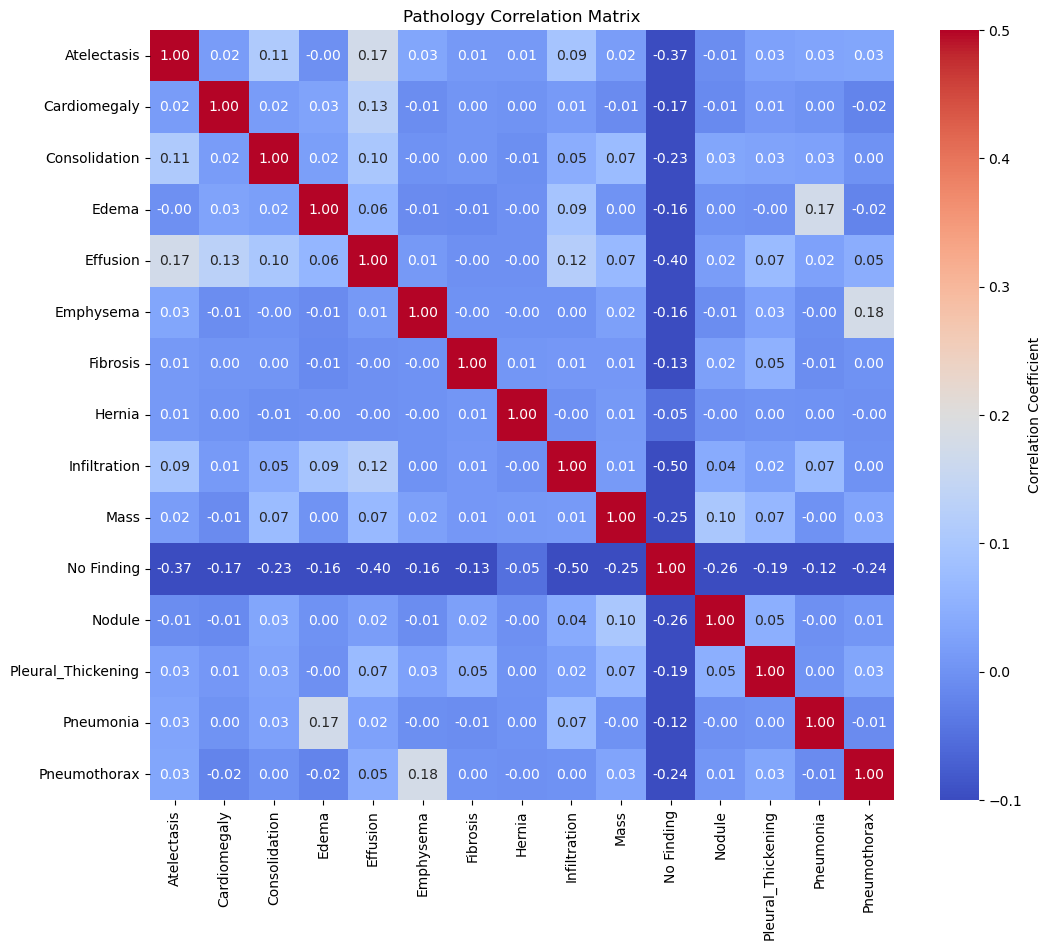

In [11]:
df['labels_list'] = df['Finding Labels'].str.split('|')
mlb = MultiLabelBinarizer()
binary_labels = mlb.fit_transform(df['labels_list'])
label_df = pd.DataFrame(binary_labels, columns=mlb.classes_)

corr_matrix = label_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-0.1, 
            vmax=0.5, 
            cbar_kws={'label': 'Correlation Coefficient'}
    )
plt.title("Pathology Correlation Matrix")
plt.show()

# Bounding Box Analysis (BBox_List_2017.csv)

In [12]:
bbox_df = pd.read_csv(BBOX_PATH)
bbox_df.head()

,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN


In [13]:
# Number of duplicate rows
duplicates_bbox = bbox_df.duplicated().sum()

# Total Bounding Boxes
total_bboxes = bbox_df.shape[0]

# Number of unique findings
unique_findings_bbox = bbox_df['Finding Label'].nunique()


print(f"Number of duplicate rows: {duplicates_bbox}")
print(f"Total Bounding Boxes: {total_bboxes}")
print(f"Number of unique findings: {unique_findings_bbox}")
print(f"Columns: {bbox_df.columns.tolist()}")

Number of duplicate rows: 0
Total Bounding Boxes: 984
Number of unique findings: 8
Columns: ['Image Index', 'Finding Label', 'Bbox [x', 'y', 'w', 'h]', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']


In [14]:
# Number of bounding boxes per image
bbox_df['Image Index'].value_counts()

Image Index
00010277_000.png    4
00008814_010.png    3
00018253_059.png    3
00018427_004.png    3
00020482_032.png    3
                   ..
00000756_001.png    1
00008522_032.png    1
00005532_000.png    1
00030206_013.png    1
00026920_000.png    1
Name: count, Length: 880, dtype: int64

In [15]:
bbox_findings = bbox_df['Finding Label'].value_counts().sort_values()
print(bbox_findings)

fig = px.bar(x=bbox_findings.values, 
             y=bbox_findings.index,
             orientation='h', 
             text=bbox_findings.values,
             title='BBox Annotation Count per Pathology',
             labels={'x': 'Count', 'y': 'Pathology Labels'},
             color=bbox_findings.values, 
             color_continuous_scale='RdYlBu'             
             )
fig.update_traces(textposition='outside')
fig.update_layout(width=800, height=600, coloraxis_showscale=False)
fig.show()

Finding Label
Nodule           79
Mass             85
Pneumothorax     98
Pneumonia       120
Infiltrate      123
Cardiomegaly    146
Effusion        153
Atelectasis     180
Name: count, dtype: int64


In [16]:
# Tendency of pathology location heatmap
def generate_pathology_heatmap(df, label, img_size=(1024, 1024)):
    # Filter for the specific disease
    subset = df[df['Finding Label'] == label]
    heatmap = np.zeros(img_size)
    
    for _, row in subset.iterrows():
        # Add 1 to every pixel inside the bounding box
        x, y, w, h = int(row['Bbox [x']), int(row['y']), int(row['w']), int(row['h]'])
        heatmap[y:y+h, x:x+w] += 1
        
    plt.imshow(heatmap, cmap='hot')
    plt.title(f'Spatial Distribution of {label}')
    plt.colorbar()
    plt.show()


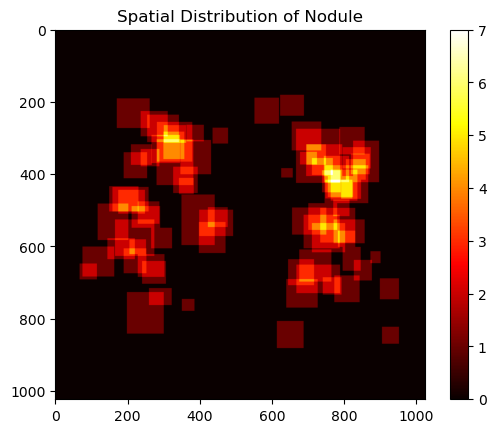

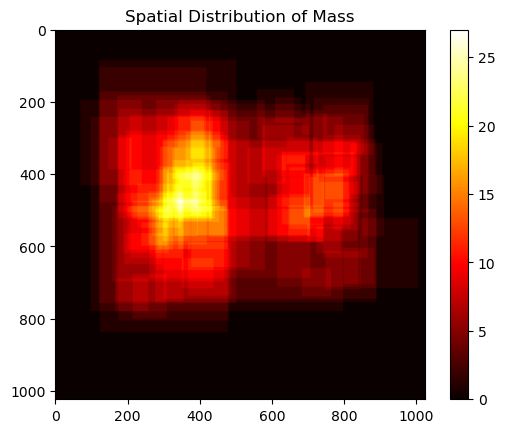

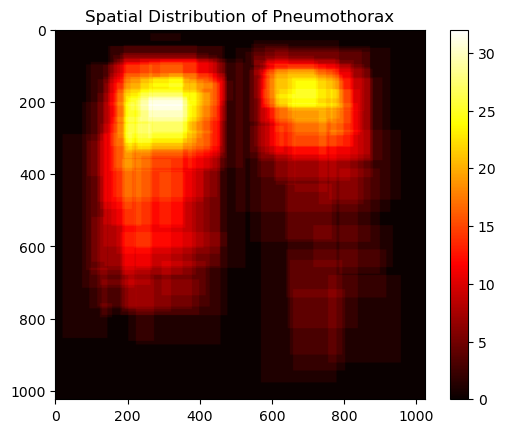

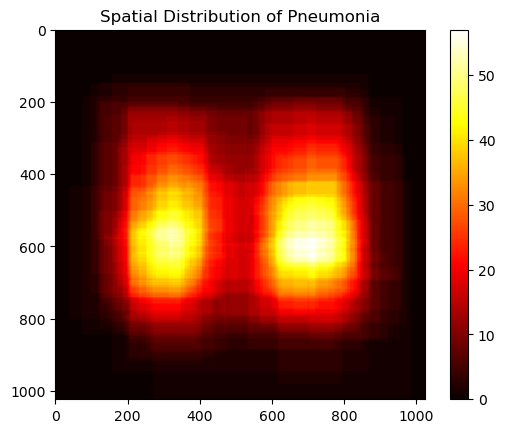

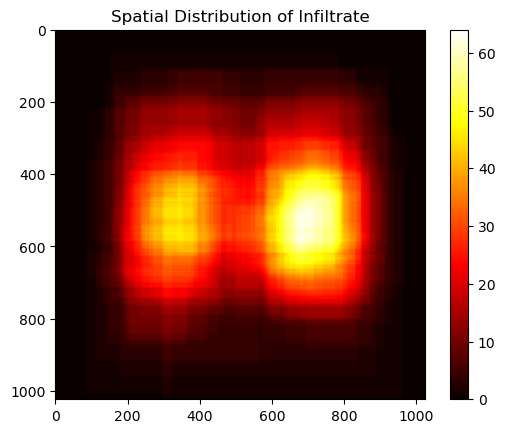

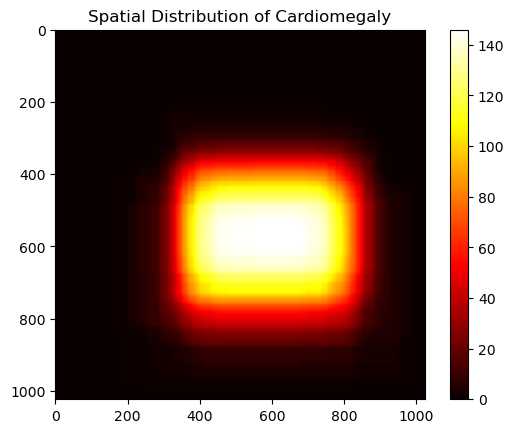

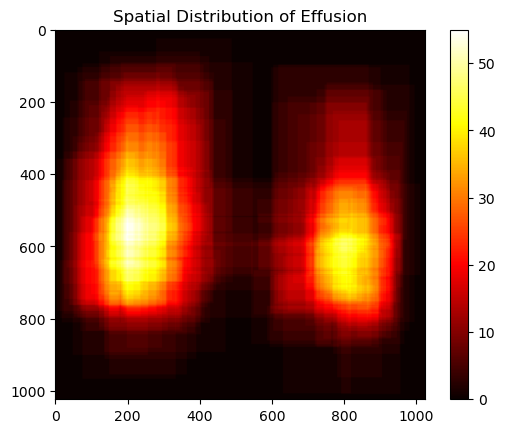

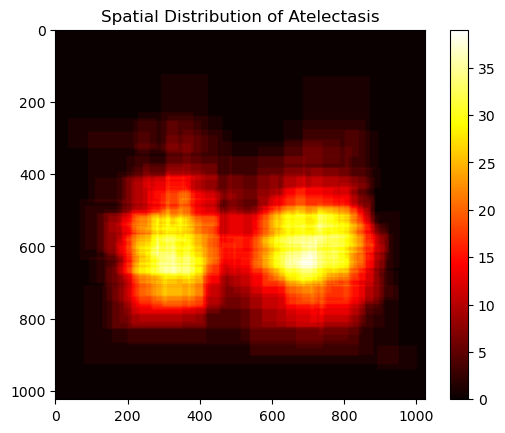

In [17]:
for finding in bbox_findings.index:
    generate_pathology_heatmap(bbox_df, finding)

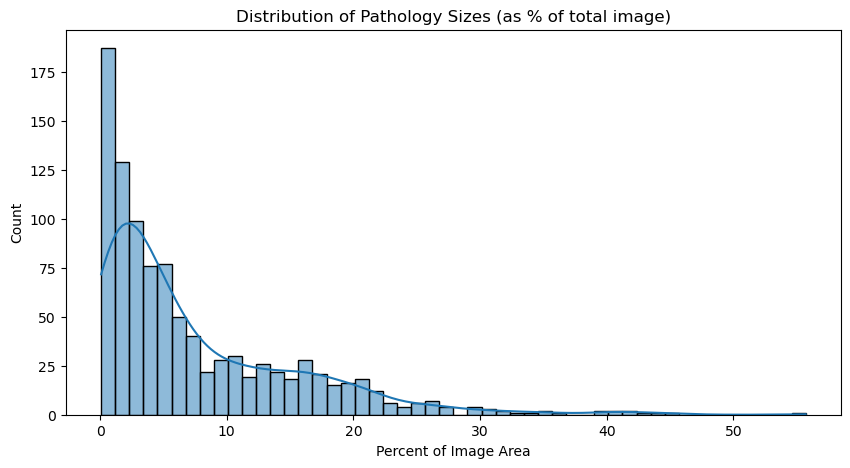

In [18]:
# Calculate relative area ( 1024x1024 images)
bbox_df['area_percentage'] = (bbox_df['w'] * bbox_df['h]']) / (1024 * 1024) * 100

plt.figure(figsize=(10, 5))
sns.histplot(bbox_df['area_percentage'], bins=50, kde=True)
plt.title('Distribution of Pathology Sizes (as % of total image)')
plt.xlabel('Percent of Image Area')
plt.show()

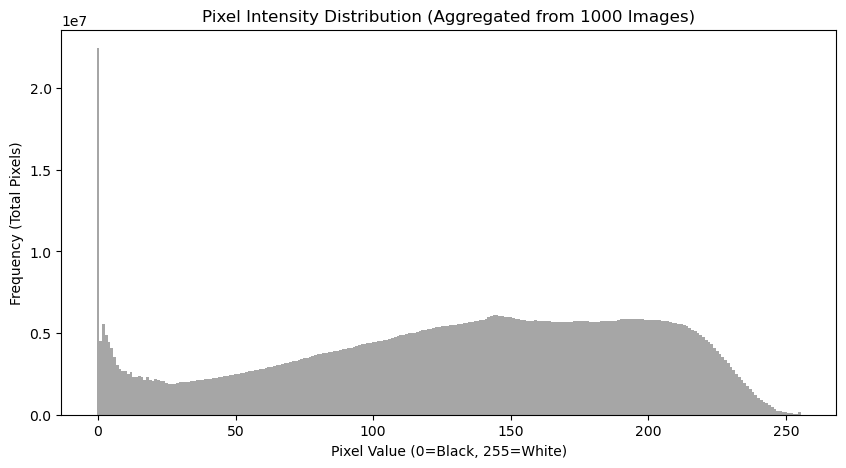

In [20]:
# Re-grab paths just in case
image_glob = glob.glob(IMAGE_PATHS)[:1000] # Limit to first 1000 for speed

# Initialize an empty array to hold the counts for 256 pixel values (0 to 255)
# RAM Friendly Method
total_pixel_counts = np.zeros(256, dtype=int)

for path in image_glob:
    img = cv2.imread(path, 0) 
    
    if img is not None:
        img_hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        
        # Add the counts from this image to our running total
        total_pixel_counts += img_hist.flatten().astype(int)

# Plot using the PRE-CALCULATED counts
plt.figure(figsize=(10, 5))
plt.bar(range(256), total_pixel_counts, color='gray', width=1.0, alpha=0.7)
plt.title(f"Pixel Intensity Distribution (Aggregated from {len(image_glob)} Images)")
plt.xlabel("Pixel Value (0=Black, 255=White)")
plt.ylabel("Frequency (Total Pixels)")
plt.show()

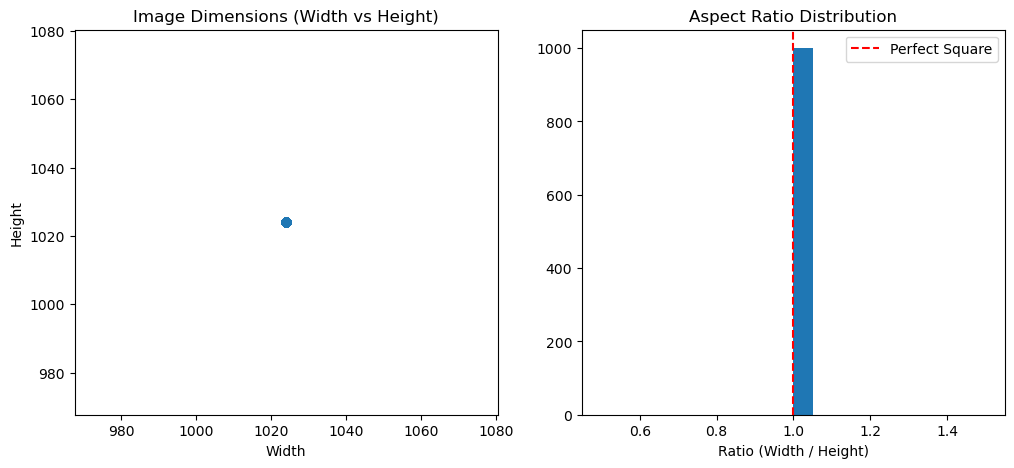

In [21]:
widths = []
heights = []
ratios = []

# Sample 1000 images
for path in image_glob[:1000]:
    img = cv2.imread(path, 0)
    if img is not None:
        h, w = img.shape
        widths.append(w)
        heights.append(h)
        ratios.append(w / h)

plt.figure(figsize=(12, 5))

# Plot 1: Scatter of Dimensions
plt.subplot(1, 2, 1)
plt.scatter(widths, heights, alpha=0.5)
plt.title("Image Dimensions (Width vs Height)")
plt.xlabel("Width")
plt.ylabel("Height")

# Plot 2: Aspect Ratio Histogram
plt.subplot(1, 2, 2)
plt.hist(ratios, bins=20)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Ratio (Width / Height)")
plt.axvline(x=1.0, color='r', linestyle='--', label="Perfect Square")
plt.legend()
plt.show()

In [22]:
# Assuming 'df' is your Data_Entry_2017 dataframe
from sklearn.model_selection import train_test_split

patients = df['Patient ID'].unique()

# Split by PATIENT, not by Image
train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

# Create the actual DataFrames
train_df = df[df['Patient ID'].isin(train_patients)]
test_df = df[df['Patient ID'].isin(test_patients)]

# Verification
overlap = set(train_df['Patient ID']).intersection(set(test_df['Patient ID']))
print(f"Number of patients in both Train and Test: {len(overlap)}") 
# This MUST be 0 in order to be blinded

Number of patients in both Train and Test: 0
